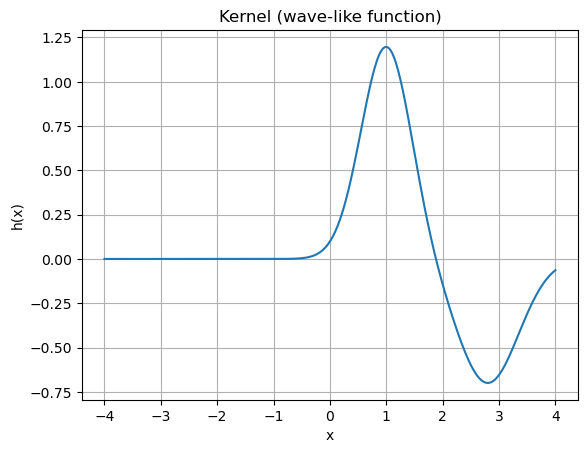

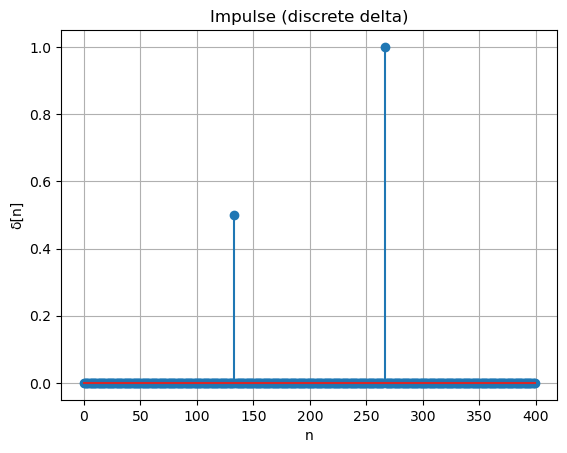

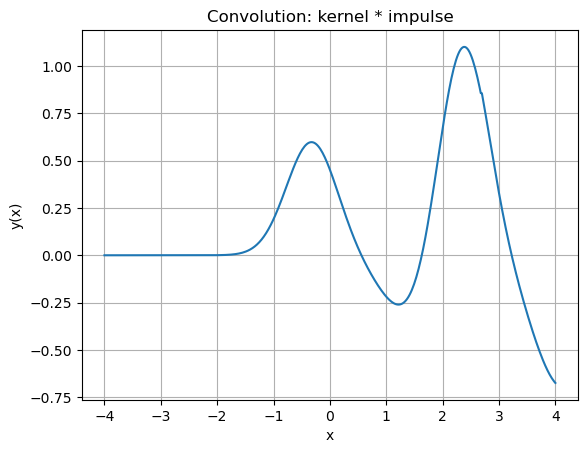

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Discrete axis
n_points = 400
x = np.linspace(-4, 4, n_points)

# 1) Define a smooth "wave-like" kernel similar to your image
kernel = (
    1.2 * np.exp(-((x + 1.5-2.5) ** 2) / 0.4)    # left bump
    - 0.7 * np.exp(-((x - 0.3-2.5) ** 2) / 0.6)  # middle dip
                                        # baseline
)

# 2) Impulse (discrete delta) centered
impulse = np.zeros_like(x)
idx1 = n_points // 3          # first impulse position
idx2 = 2 * n_points // 3      # second impulse position

impulse[idx1] = 0.5           # amplitude of first impulse
impulse[idx2] = 1          # amplitude of second impulse

# 3) Convolution of kernel with impulse
conv = np.convolve(kernel, impulse, mode="same")

# ---- PLOTS ----

# Plot kernel
plt.figure()
plt.plot(x, kernel)
plt.title("Kernel (wave-like function)")
plt.xlabel("x")
plt.ylabel("h(x)")
plt.grid(True)

# Plot impulse (use discrete index instead of x for clarity)
n = np.arange(len(x))
plt.figure()
plt.stem(n, impulse)
plt.title("Impulse (discrete delta)")
plt.xlabel("n")
plt.ylabel("δ[n]")
plt.grid(True)

# Plot convolution result
plt.figure()
plt.plot(x, conv)
plt.title("Convolution: kernel * impulse")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid(True)

plt.show()


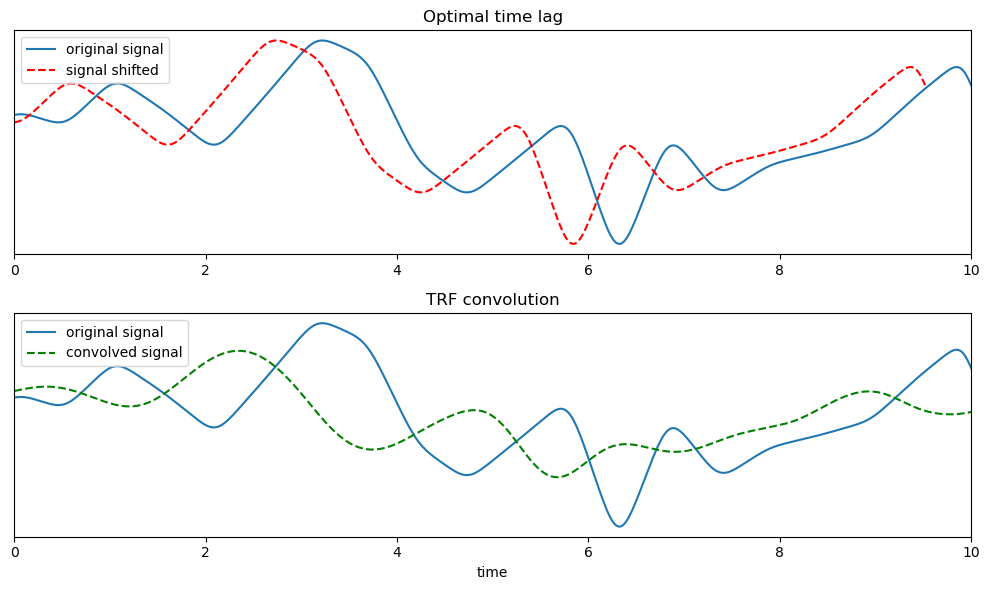

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1) Smooth, non-sinusoidal wave
# ---------------------------
n_points = 500
x = np.linspace(0, 10, n_points)

# Random control points
n_ctrl = 20
x_ctrl = np.linspace(0, 10, n_ctrl)

rng = np.random.default_rng(0)          # seed for reproducibility
y_ctrl = rng.normal(loc=0.0, scale=1.0, size=n_ctrl)

# Connect the dots (linear interpolation)
wave_raw = np.interp(x, x_ctrl, y_ctrl)

# Smooth the connections with a Gaussian filter
klen = 31
n = np.arange(klen) - (klen - 1) / 2
sigma = 5
smooth_kernel = np.exp(-(n**2) / (2 * sigma**2))
smooth_kernel /= smooth_kernel.sum()

wave = np.convolve(wave_raw, smooth_kernel, mode="same") * 0.7

# ---------------------------
# 2) Your convolution kernel
# ---------------------------
t = np.linspace(-4, 4, 201)
kernel = (
    1.2 * np.exp(-((t + 1.5) ** 2) / 0.4)    # left bump
    - 0.7 * np.exp(-((t - 0.3) ** 2) / 0.6)  # middle dip
    + 0.3                                    # baseline
)
kernel = kernel / np.sum(kernel)            # optional normalization

# Convolved wave
conv = np.convolve(wave, kernel, mode="same")

# ---------------------------
# 3) Shifted version of the wave (shift by +1 in x)
# ---------------------------
dx = x[1] - x[0]
shift = 0.5                         # shift by 1 unit in x
samples_shift = int(shift / dx)     # number of samples

# shift to the right by "samples_shift" samples
wave_shifted = np.roll(wave, -samples_shift)
# (optional) set the first samples to NaN so the shift is visually clear
wave_shifted[-samples_shift:] = np.nan

# ---------------------------
# 4) Plots: two stacked subplots
# ---------------------------
plt.figure(figsize=(10, 6))

# ---- Top: original wave and shifted wave ----
plt.subplot(2, 1, 1)
plt.plot(x, wave, label="original signal")
plt.plot(x, wave_shifted, 'r--', label="signal shifted")
plt.title("Optimal time lag")
plt.xlim(0, 10)
plt.yticks([])
plt.grid(False)
plt.legend()

# ---- Bottom: original wave and convolved wave ----
plt.subplot(2, 1, 2)
plt.plot(x, wave, label="original signal")
plt.plot(x, conv, 'g--', label="convolved signal")
plt.title("TRF convolution")
plt.xlabel("time")
plt.yticks([])
plt.xlim(0, 10)
plt.grid(False)
plt.legend()

plt.tight_layout()
plt.show()


In [19]:
%matplotlib qt
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1) Discrete axis
# ---------------------------
n_points = 500
x = np.linspace(0, 10, n_points)
dx = x[1] - x[0]

# ---------------------------
# 2) "Wave" = two impulses
# ---------------------------
wave = np.zeros(n_points)

idx1 = n_points // 2          # position of first impulse
idx2 = 2 * n_points // 3      # position of second impulse

wave[idx1] = 1.0              # amplitude 1
wave[idx2] = 0.5              # amplitude 0.5

# ---------------------------
# 3) Convolution kernel
# ---------------------------
t = np.linspace(-4, 4, 201)
kernel = (
    1.2 * np.exp(-((t + 1.5) ** 2) / 0.4)    # left bump
    - 0.7 * np.exp(-((t - 0.3) ** 2) / 0.6)  # middle dip
)

conv = np.convolve(wave, kernel, mode="same")

# ---------------------------
# 4) Shift the impulse signal by -1 in x (left)
# ---------------------------
shift = -1.0                         # shift by -1 in x
samples_shift = int(abs(shift) / dx) # number of samples

wave_shifted = np.zeros_like(wave)
if samples_shift < n_points:
    wave_shifted[:-samples_shift] = wave[samples_shift:]

# ---------------------------
# 5) Plots (with small kernel inset)
# ---------------------------
fig = plt.figure(figsize=(10, 6))

# Top subplot
ax1 = fig.add_subplot(2, 1, 1)
ax1.stem(x, wave, linefmt='b-', markerfmt=' ', basefmt=' ', label="original signal")
ax1.axhline(0, linewidth=0.8)
ax1.plot(x, wave_shifted, "r--", label="shifted signal")
ax1.set_xlim(0, 10)
ax1.set_title("Optimal time lag")
ax1.grid(False)
ax1.legend()
ax1.set_yticks([])

# Bottom subplot
ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)
ax2.stem(x, wave, linefmt='b-', markerfmt=' ', basefmt=' ', label="original signal")
ax2.axhline(0, linewidth=0.8)
ax2.plot(x, conv, "g--", label="convolved signal")
ax2.set_title("TRF convolution")
ax2.set_xlabel("time")
ax2.grid(False)
ax2.legend()
ax2.set_yticks([])

# --- Smaller kernel inset, top-left, no grid, thicker line ---
# [left, bottom, width, height] in figure coordinates
kernel_ax = fig.add_axes([0.09, 0.22, 0.16, 0.16])
kernel_ax.plot(t, kernel, linewidth=2)
kernel_ax.set_title("kernel")
kernel_ax.tick_params(axis='both')
kernel_ax.grid(False)          # no grid
# Optional: hide ticks for a cleaner "icon" look
kernel_ax.set_xticks([])
kernel_ax.set_yticks([])

plt.tight_layout()
plt.show()


C:\Users\cdd\AppData\Local\Temp\ipykernel_5036\1695859882.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


## PLOTS

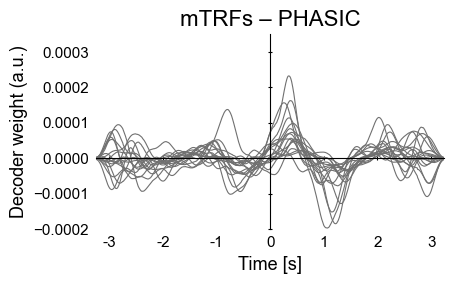

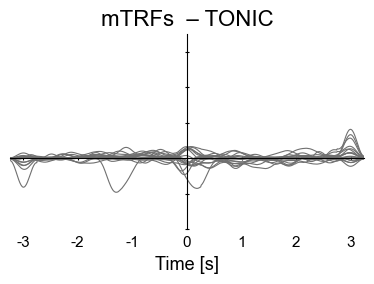

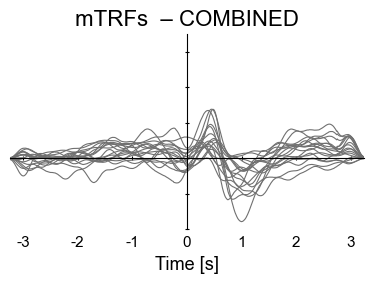

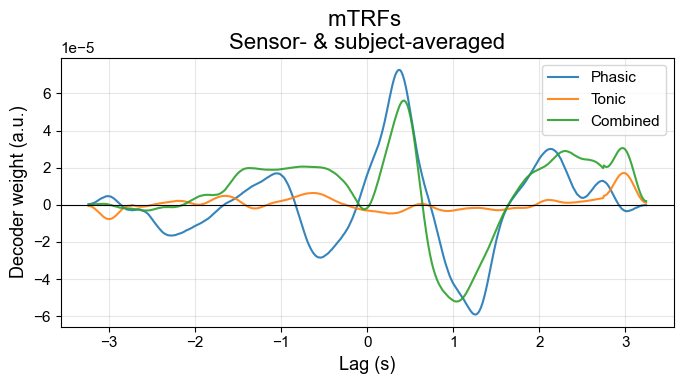

In [ ]:
from pathlib import Path
import re
import numpy as np
import eelbrain
from matplotlib import pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})


def get_decoder(trf_dir: Path):
    cases = []
    for f in trf_dir.glob("dec_eeg_to_ppd_sub-*_l*.pickle"):
        m = re.match(r"dec_eeg_to_ppd_sub-(\d+)_l(\d+)\.pickle", f.name)
        if not m:
            continue
        subj = f"S{int(m.group(1)):03d}"
        load_val = int(m.group(2))

        dec = eelbrain.load.unpickle(f)

        trf = dec.h_scaled                     # NDVar(sensor × time): decoder weights
        r_val = float(dec.r)                   # scalar correlation
        ve = float(dec.proportion_explained) * 100  # % variance explained

        cases.append([subj, load_val, trf, r_val, ve])

    dataset_dec = eelbrain.Dataset.from_caselist(
        ['subject', 'load', 'trf_dec', 'r', 'var_explained'],
        cases,
        random='subject'
    )
    return dataset_dec


# -------------------------------------------------------------------
# 1) Paths for the three models
# -------------------------------------------------------------------
TRF_PHASIC   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\ran12\TRF")
TRF_TONIC    = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran04\TRF")
TRF_COMBINED = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\TRF")

# Load all three
ds_phasic   = get_decoder(TRF_PHASIC)
ds_tonic    = get_decoder(TRF_TONIC)
ds_combined = get_decoder(TRF_COMBINED)

trf_phasic_all   = ds_phasic['trf_dec']     # NDVar(case × sensor × time)
trf_tonic_all    = ds_tonic['trf_dec']
trf_combined_all = ds_combined['trf_dec']


# -------------------------------------------------------------------
# 2) Butterfly plots – one figure per model (Eelbrain handles its own axes)
# -------------------------------------------------------------------
vmin, vmax = -0.0002, 0.00035  # adjust if needed


eelbrain.plot.Butterfly(
    trf_phasic_all,
    vmin=vmin, vmax=vmax,
    linewidth=0.8,
    color='#707070',
    frame='t',
    ylabel="Decoder weight (a.u.)",
    clip=True,
    axtitle="mTRFs – PHASIC",
    h=3, w=4.7,
)

eelbrain.plot.Butterfly(
    trf_tonic_all,
    vmin=vmin, vmax=vmax,
    linewidth=0.8,
    color='#707070',
    frame='t',
    clip=True,
    axtitle="mTRFs  – TONIC",
    yticklabels=False,  # hide y tick labels
    ylabel='',
    h=3, w=3.9,
)

eelbrain.plot.Butterfly(
    trf_combined_all,
    vmin=vmin, vmax=vmax,
    linewidth=0.8,
    color='#707070',
    frame='t',
    clip=True,
    axtitle="mTRFs  – COMBINED",
    yticklabels=False,  # hide y tick labels
    ylabel='',
    h=3, w=3.9,
)


# -------------------------------------------------------------------
# 3) Overlaid timecourses (sensor & subject averaged) – pure matplotlib
# -------------------------------------------------------------------
# Average over sensors, then over cases → 1D TRF(time) per model
trf_phasic_mean   = trf_phasic_all.mean('sensor').mean('case')     # NDVar(time)
trf_tonic_mean    = trf_tonic_all.mean('sensor').mean('case')
trf_combined_mean = trf_combined_all.mean('sensor').mean('case')

time = trf_phasic_mean.time   # time axis in seconds
y_phasic   = trf_phasic_mean.x
y_tonic    = trf_tonic_mean.x
y_combined = trf_combined_mean.x

plt.figure(figsize=(7, 4))
plt.plot(time, y_phasic,   label='Phasic',   alpha=0.9)
plt.plot(time, y_tonic,    label='Tonic',    alpha=0.9)
plt.plot(time, y_combined, label='Combined', alpha=0.9)

plt.axhline(0, color='k', linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Decoder weight (a.u.)")
plt.title("mTRFs \nSensor- & subject-averaged")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
NOT_EVAL_SUBS = [35, 46, 60, 68, 97]  # subjects not evaluated due to too few trials
SUBJECTS = np.setdiff1d(SUBJECTS, NOT_EVAL_SUBS)
PLOT_SUBS = [49, 63, 74]


for sub in range(len(SUBJECTS)):
    if SUBJECTS[sub] not in PLOT_SUBS:
        continue
    trf_phasic_mean   = trf_phasic_all.mean('sensor')[sub]   # NDVar(time)
    trf_tonic_mean    = trf_tonic_all.mean('sensor')[sub]
    trf_combined_mean = trf_combined_all.mean('sensor')[sub]

    time = trf_phasic_mean.time   # time axis in seconds
    y_phasic   = trf_phasic_mean.x
    y_tonic    = trf_tonic_mean.x
    y_combined = trf_combined_mean.x

    
    plt.figure(figsize=(5, 3))
    plt.plot(time, y_phasic,   label='Phasic',   alpha=0.9)
    plt.plot(time, y_tonic,    label='Tonic',    alpha=0.9)
    plt.plot(time, y_combined, label='Combined', alpha=0.9)

    plt.axhline(0, color='k', linewidth=0.8)
    plt.axvline(0, color='k', linewidth=0.8)
    plt.xlabel("time (s)")
    plt.title("mTRFs Sub " + str(SUBJECTS[sub]))
    if SUBJECTS[sub] == PLOT_SUBS[0]:
        plt.ylabel("Decoder weight (a.u.)")
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [78]:
import numpy as np
from matplotlib import pyplot as plt

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
NOT_EVAL_SUBS = [35, 46, 60, 68, 97]  # subjects not evaluated due to too few trials
SUBJECTS = np.setdiff1d(SUBJECTS, NOT_EVAL_SUBS)
PLOT_SUBS = [49, 63, 74]

# Find the indices in the NDVar that correspond to the subjects we want
idxs_to_plot = [np.where(SUBJECTS == s)[0][0] for s in PLOT_SUBS]

fig, axes = plt.subplots(1, len(PLOT_SUBS), figsize=(10, 3), sharey=True)

for ax, idx, subj in zip(axes, idxs_to_plot, PLOT_SUBS):
    # average over sensors for this subject (case index = idx)
    trf_phasic_mean   = trf_phasic_all.mean('sensor')[idx]   # NDVar(time)
    trf_tonic_mean    = trf_tonic_all.mean('sensor')[idx]
    trf_combined_mean = trf_combined_all.mean('sensor')[idx]

    time = trf_phasic_mean.time # time axis as numpy array
    y_phasic   = trf_phasic_mean.x
    y_tonic    = trf_tonic_mean.x
    y_combined = trf_combined_mean.x

    ax.plot(time, y_phasic,   label='Phasic',   alpha=0.9)
    ax.plot(time, y_tonic,    label='Tonic',    alpha=0.9)
    ax.plot(time, y_combined, label='Combined', alpha=0.9)

    ax.axhline(0, color='k', linewidth=0.8)
    ax.axvline(0, color='k', linewidth=0.8)

    ax.set_xlabel("time (s)")
    ax.set_title(f"mTRFs Sub {subj}")

    # Only put ylabel + legend on the first subplot
    if subj == PLOT_SUBS[0]:
        ax.set_ylabel("Decoder weight (a.u.)")
        ax.legend()

    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


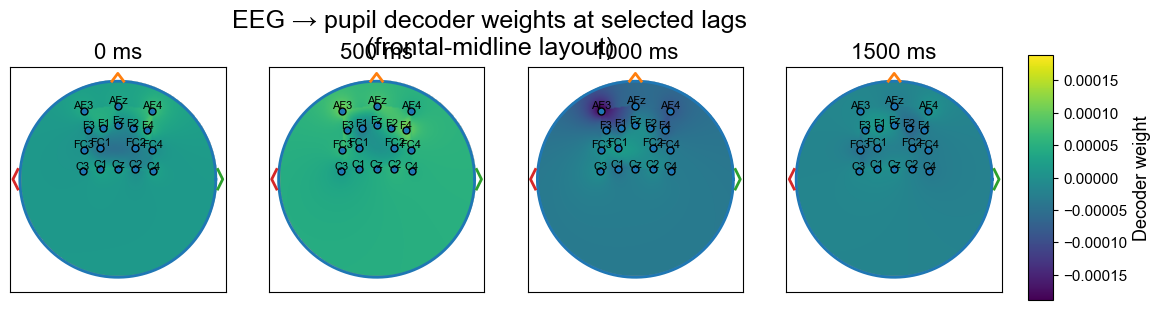

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# Try to use SciPy's griddata for smooth interpolation; fallback to IDW if unavailable.
try:
    from scipy.interpolate import griddata
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

POS = {
    "AFz": (0.0,  0.75),
    "AF3": (-0.35, 0.70),
    "AF4": ( 0.35, 0.70),

    "Fz":  (0.0,  0.55),
    "F1":  (-0.15, 0.52),
    "F2":  ( 0.15, 0.52),
    "F3":  (-0.30, 0.50),
    "F4":  ( 0.30, 0.50),

    "FC1": (-0.18, 0.32),
    "FC2": ( 0.18, 0.32),
    "FC3": (-0.35, 0.30),
    "FC4": ( 0.35, 0.30),

    "Cz":  (0.0,  0.10),
    "C1":  (-0.18, 0.10),
    "C2":  ( 0.18, 0.10),
    "C3":  (-0.36, 0.08),
    "C4":  ( 0.36, 0.08),
}

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

def idw_interpolate(points, values, gx, gy, power=2.0, eps=1e-12):
    px = points[:, 0][:, None, None]
    py = points[:, 1][:, None, None]
    dx = gx[None, :, :] - px
    dy = gy[None, :, :] - py
    d2 = dx*dx + dy*dy
    w = 1.0 / (d2 + eps)**(power/2)
    num = (w * values[:, None, None]).sum(axis=0)
    den = w.sum(axis=0)
    return num / (den + eps)

def compute_grid(z, xy, GX, GY, mask, normalise=False):
    z = np.asarray(z, dtype=float)

    # Always define z_std
    if normalise:
        mu = z.mean()
        sd = z.std(ddof=0)
        if sd == 0:
            z_std = np.zeros_like(z)
        else:
            z_std = (z - mu) / sd
    else:
        z_std = z

    if _HAS_SCIPY:
        GZ = griddata(xy, z_std, (GX, GY), method="cubic")
        nan_mask = np.isnan(GZ)
        if nan_mask.any():
            GZ_idw = idw_interpolate(xy, z_std, GX, GY, power=2.0)
            GZ[nan_mask] = GZ_idw[nan_mask]
    else:
        GZ = idw_interpolate(xy, z_std, GX, GY, power=2.0)

    GZ_masked = np.ma.array(GZ, mask=~mask)
    return GZ_masked
# ------------------------------------------------------------
# 1) Choose times and labels (same as your Eelbrain example)
# ------------------------------------------------------------
times_topo  = [0.0, 0.5, 1.0, 1.5]  # seconds
labels_topo = [f"{int(t*1000)} ms" for t in times_topo]

# ------------------------------------------------------------
# 2) Map FRONTAL_MIDLINE names → indices in the TRF NDVar
# ------------------------------------------------------------
trf_mean_dec = trf_phasic_all.mean('case')
sensor_names = np.array(trf_mean_dec.sensor.names)

idx = []
for ch in FRONTAL_MIDLINE:
    if ch not in sensor_names:
        raise ValueError(f"Channel {ch} not found in TRF sensors: {sensor_names}")
    idx.append(np.where(sensor_names == ch)[0][0])
idx = np.array(idx)

# ------------------------------------------------------------
# 3) Build interpolated scalp grids for each time
# ------------------------------------------------------------
# --- Geometry / grid for topomaps ---
xy = np.array([POS[ch] for ch in FRONTAL_MIDLINE])

N = 200
grid_x = np.linspace(-1.0, 1.0, N)
grid_y = np.linspace(-1.0, 1.0, N)
GX, GY = np.meshgrid(grid_x, grid_y)
mask = (GX**2 + GY**2) <= 1.0

GZ_list = []
for t in times_topo:
    # sensor-only slice at this time (shape: n_sensors,)
    trf_t_all = trf_mean_dec.sub(time=t).x
    # keep only the frontal-midline channels, in the order of FRONTAL_MIDLINE
    vals = trf_t_all[idx]
    # interpolate onto scalp grid with your helper
    GZ = compute_grid(vals, xy, GX, GY, mask)
    GZ_list.append(GZ)

# ------------------------------------------------------------
# 4) Common symmetric color scale over all maps
# ------------------------------------------------------------
vmin = min(float(GZ.min()) for GZ in GZ_list)
vmax = max(float(GZ.max()) for GZ in GZ_list)
v = max(abs(vmin), abs(vmax))
norm = plt.Normalize(vmin=-v, vmax=v)

# individual scaling like Eelbrain
norms = []
for GZ in GZ_list:
    v = np.nanmax(np.abs(GZ))
    norms.append(plt.Normalize(vmin=-v, vmax=v))


# ------------------------------------------------------------
# 5) Plot: one scalp map per time point, using your head layout
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(times_topo), figsize=(3.2 * len(times_topo), 3.5))

if len(times_topo) == 1:
    axes = [axes]  # make iterable

for ax, GZ, label, norm_i in zip(axes, GZ_list, labels_topo, norms):
    im = ax.imshow(
        GZ,
        origin="lower",
        extent=(-1, 1, -1, 1),
        interpolation="bicubic",
        #cmap="RdBu_r",
        norm=norm,
    )

    # --- head outline ---
    theta = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), linewidth=2)

    # nose
    nose_x = np.array([-0.06, 0.0, 0.06])
    nose_y = np.array([1.00, 1.08, 1.00])
    ax.plot(nose_x, nose_y, linewidth=2)

    # ears
    ear_x = np.array([1.02, 1.07, 1.02])
    ear_y = np.array([0.10, 0.00, -0.10])
    ax.plot( ear_x,  ear_y, linewidth=2)
    ax.plot(-ear_x,  ear_y, linewidth=2)

    # electrodes + labels (from your POS / FRONTAL_MIDLINE)
    ex, ey = xy[:, 0], xy[:, 1]
    ax.scatter(ex, ey, s=25, edgecolors="k")
    for ch, (cx, cy) in POS.items():
        ax.text(cx, cy, ch, ha="center", va="bottom", fontsize=8)

    ax.set_aspect("equal")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(label)

# ------------------------------------------------------------
# 6) Shared colorbar + title
# ------------------------------------------------------------
fig.subplots_adjust(right=0.9)
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Decoder weight")

fig.suptitle("EEG → pupil decoder weights at selected lags\n(frontal-midline layout)")
plt.show()


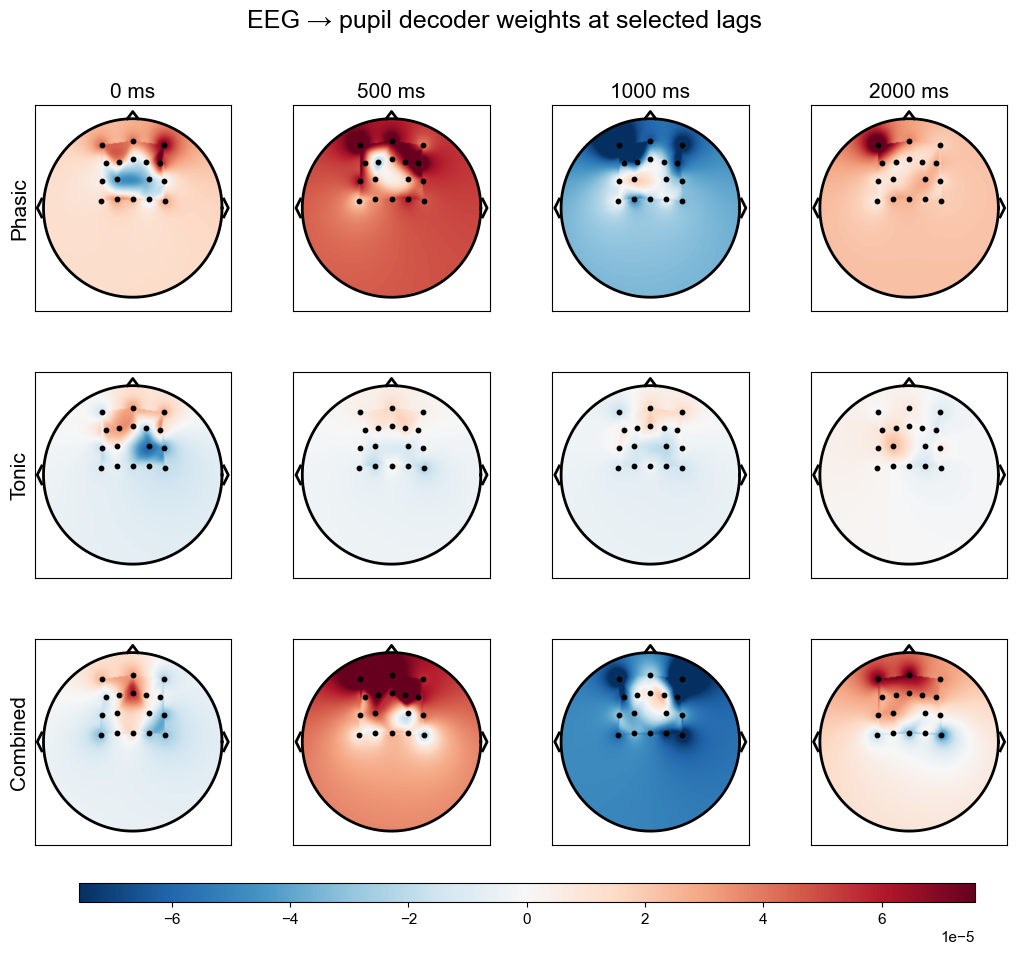

In [4]:
# ------------------------------------------------------------
# 1) Times and labels
# ------------------------------------------------------------
times_topo  = [0.0, 0.5, 1.0, 2]  # seconds
labels_topo = [f"{int(t*1000)} ms" for t in times_topo]

# ------------------------------------------------------------
# 2) Geometry / grid for topomaps
# ------------------------------------------------------------
xy = np.array([POS[ch] for ch in FRONTAL_MIDLINE])

N = 200
grid_x = np.linspace(-1.0, 1.0, N)
grid_y = np.linspace(-1.0, 1.0, N)
GX, GY = np.meshgrid(grid_x, grid_y)
mask = (GX**2 + GY**2) <= 1.0

# ------------------------------------------------------------
# 3) Map channel names -> indices (use phasic just to get sensors)
# ------------------------------------------------------------
trf_ref = trf_phasic_all.mean('case')   # just for sensor layout
sensor_names = np.array(trf_ref.sensor.names)

idx = []
for ch in FRONTAL_MIDLINE:
    if ch not in sensor_names:
        raise ValueError(f"Channel {ch} not found in TRF sensors: {sensor_names}")
    idx.append(np.where(sensor_names == ch)[0][0])
idx = np.array(idx)

# ------------------------------------------------------------
# 4) Build interpolated grids for each TRF type & time
# ------------------------------------------------------------
trf_sets = {
    "Phasic":   trf_phasic_all.mean('case'),
    "Tonic":    trf_tonic_all.mean('case'),
    "Combined": trf_combined_all.mean('case'),
}

GZ_all = {}   # name -> list of GZ (one per time)
for name, trf_mean in trf_sets.items():
    GZ_list = []
    for t in times_topo:
        trf_t_all = trf_mean.sub(time=t).x       # shape: (n_sensors,)
        vals = trf_t_all[idx]                    # keep only FRONTAL_MIDLINE
        GZ = compute_grid(vals, xy, GX, GY, mask)
        GZ_list.append(GZ)
    GZ_all[name] = GZ_list

# ------------------------------------------------------------
# 5) Global symmetric color scale across ALL maps
# ------------------------------------------------------------
all_vals = np.concatenate([np.ravel(GZ.data) for GZ_list in GZ_all.values() for GZ in GZ_list])
v = np.nanmax(np.abs(all_vals))*0.4
norm = plt.Normalize(vmin=-v, vmax=v)

# ------------------------------------------------------------
# 6) Plot: rows = {phasic, tonic, combined}, cols = times
# ------------------------------------------------------------
n_rows = len(trf_sets)
n_cols = len(times_topo)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
axes = np.atleast_2d(axes)

row_names = list(trf_sets.keys())

for r, name in enumerate(row_names):
    GZ_list = GZ_all[name]
    for c, (GZ, t_label) in enumerate(zip(GZ_list, labels_topo)):
        ax = axes[r, c]

        im = ax.imshow(
            GZ,
            origin="lower",
            extent=(-1, 1, -1, 1),
            interpolation="bicubic",
            cmap="RdBu_r",
            norm=norm,        # same scale for all maps
        )

        # --- head outline ---
        theta = np.linspace(0, 2*np.pi, 400)
        ax.plot(np.cos(theta), np.sin(theta), linewidth=2, color="k")

        # nose
        nose_x = np.array([-0.06, 0.0, 0.06])
        nose_y = np.array([1.00, 1.08, 1.00])
        ax.plot(nose_x, nose_y, linewidth=2, color="k")

        # ears
        ear_x = np.array([1.02, 1.07, 1.02])
        ear_y = np.array([0.10, 0.00, -0.10])
        ax.plot( ear_x,  ear_y, linewidth=2, color="k")
        ax.plot(-ear_x,  ear_y, linewidth=2, color="k")

        # electrodes (no labels if you want it cleaner; keep if you like)
        ex, ey = xy[:, 0], xy[:, 1]
        ax.scatter(ex, ey, s=10, edgecolors="k", facecolors="k")

        ax.set_aspect("equal")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.15, 1.15)
        ax.set_xticks([])
        ax.set_yticks([])

        # Column titles only on top row
        if r == 0:
            ax.set_title(t_label, fontsize=15)

        # Row labels only on leftmost column
        if c == 0:
            ax.set_ylabel(name, fontsize=15)

# ------------------------------------------------------------
# 7) Shared colorbar + title
# ------------------------------------------------------------
fig.subplots_adjust(right=0.9, wspace=0.2, hspace=0.3)
cax = fig.add_axes([0.167, 0.05, 0.7, 0.02])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')

fig.suptitle("EEG → pupil decoder weights at selected lags", y=0.98)
plt.show()


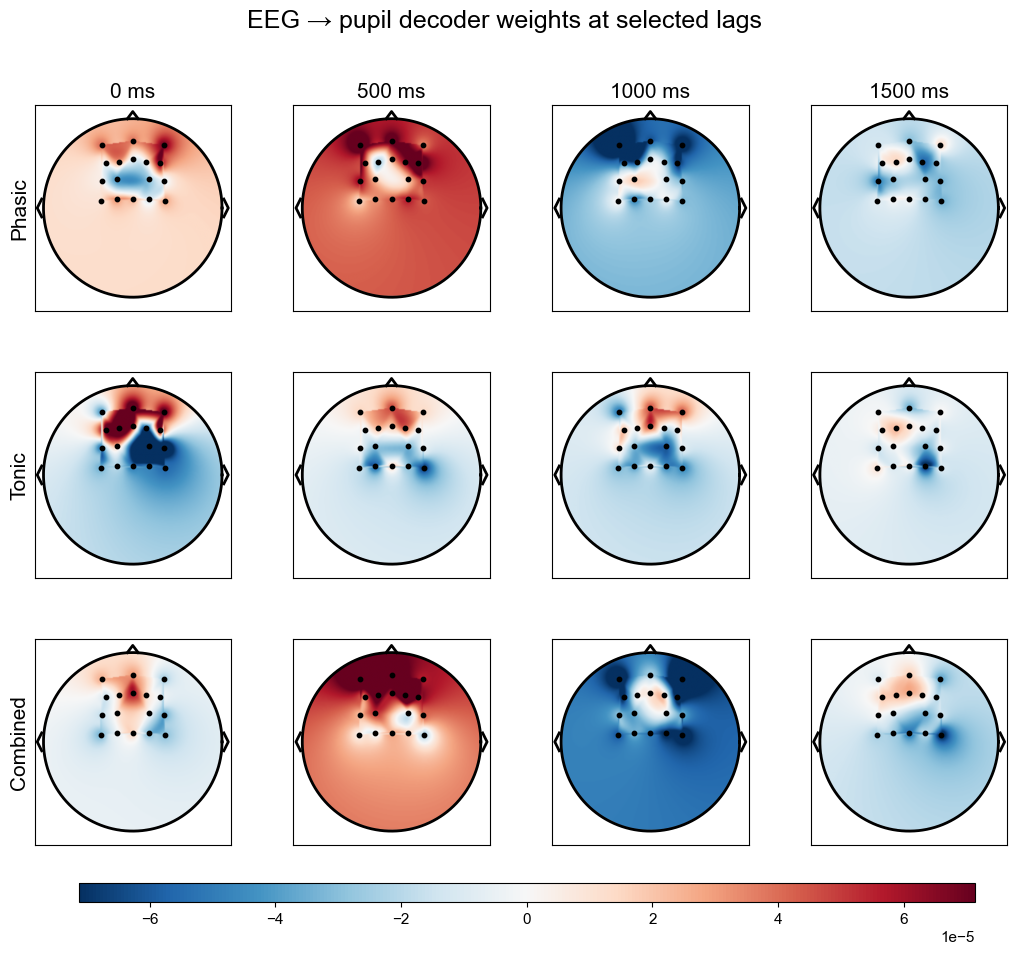

In [5]:
# ------------------------------------------------------------
# 1) Times and labels
# ------------------------------------------------------------
times_topo  = [0.0, 0.5, 1.0, 1.5]  # seconds
labels_topo = [f"{int(t*1000)} ms" for t in times_topo]

# ------------------------------------------------------------
# 2) Geometry / grid for topomaps
# ------------------------------------------------------------
xy = np.array([POS[ch] for ch in FRONTAL_MIDLINE])

N = 200
grid_x = np.linspace(-1.0, 1.0, N)
grid_y = np.linspace(-1.0, 1.0, N)
GX, GY = np.meshgrid(grid_x, grid_y)
mask = (GX**2 + GY**2) <= 1.0

# ------------------------------------------------------------
# 3) Map channel names -> indices (use phasic just to get sensors)
# ------------------------------------------------------------
trf_ref = trf_phasic_all.mean('case')   # reference for sensor layout
sensor_names = np.array(trf_ref.sensor.names)

idx = []
for ch in FRONTAL_MIDLINE:
    if ch not in sensor_names:
        raise ValueError(f"Channel {ch} not found in TRF sensors: {sensor_names}")
    idx.append(np.where(sensor_names == ch)[0][0])
idx = np.array(idx)

# ------------------------------------------------------------
# 4) Build interpolated grids for each TRF type & time
# ------------------------------------------------------------
trf_sets = {
    "Phasic":   trf_phasic_all.mean('case'),
    "Tonic":    trf_tonic_all.mean('case'),
    "Combined": trf_combined_all.mean('case'),
}

GZ_all = {}   # name -> list of GZ (one per time)
for name, trf_mean in trf_sets.items():
    GZ_list = []
    for t in times_topo:
        trf_t_all = trf_mean.sub(time=t).x       # shape: (n_sensors,)
        vals = trf_t_all[idx]                    # keep only FRONTAL_MIDLINE
        GZ = compute_grid(vals, xy, GX, GY, mask)
        GZ_list.append(GZ)
    GZ_all[name] = GZ_list

# ------------------------------------------------------------
# 5) One symmetric color scale PER ROW (per phasic / tonic / combined)
# ------------------------------------------------------------
norms = {}  # name -> Normalize
for name, GZ_list in GZ_all.items():
    all_vals_row = np.concatenate([GZ.data.ravel() for GZ in GZ_list])
    v_row = np.nanmax(np.abs(all_vals_row))*0.4
    norms[name] = plt.Normalize(vmin=-v_row, vmax=v_row)

# ------------------------------------------------------------
# 6) Plot: rows = {phasic, tonic, combined}, cols = times
# ------------------------------------------------------------
row_names = list(trf_sets.keys())
n_rows = len(row_names)
n_cols = len(times_topo)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
axes = np.atleast_2d(axes)

for r, name in enumerate(row_names):
    GZ_list = GZ_all[name]
    norm_row = norms[name]
    for c, (GZ, t_label) in enumerate(zip(GZ_list, labels_topo)):
        ax = axes[r, c]

        im = ax.imshow(
            GZ,
            origin="lower",
            extent=(-1, 1, -1, 1),
            interpolation="bicubic",
            cmap="RdBu_r",
            norm=norm_row,     # 🔹 same scale within this row only
        )

        # --- head outline ---
        theta = np.linspace(0, 2*np.pi, 400)
        ax.plot(np.cos(theta), np.sin(theta), linewidth=2, color="k")

        # nose
        nose_x = np.array([-0.06, 0.0, 0.06])
        nose_y = np.array([1.00, 1.08, 1.00])
        ax.plot(nose_x, nose_y, linewidth=2, color="k")

        # ears
        ear_x = np.array([1.02, 1.07, 1.02])
        ear_y = np.array([0.10, 0.00, -0.10])
        ax.plot( ear_x,  ear_y, linewidth=2, color="k")
        ax.plot(-ear_x,  ear_y, linewidth=2, color="k")

        # electrodes (no labels to keep it clean; add if you like)
        ex, ey = xy[:, 0], xy[:, 1]
        ax.scatter(ex, ey, s=10, edgecolors="k", facecolors="k")

        ax.set_aspect("equal")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.15, 1.15)
        ax.set_xticks([])
        ax.set_yticks([])

        # Column titles only on top row
        if r == 0:
            ax.set_title(t_label, fontsize=15)

        # Row labels only on leftmost column
        if c == 0:
            ax.set_ylabel(name, fontsize=15)

# ------------------------------------------------------------
# 7) Colorbar + title
# ------------------------------------------------------------
fig.subplots_adjust(right=0.9, wspace=0.2, hspace=0.3)
cax = fig.add_axes([0.167, 0.05, 0.7, 0.02])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')

fig.suptitle("EEG → pupil decoder weights at selected lags", y=0.98)
plt.show()


HISTOGRAMS of r_dec

Phasic: 52 rows (subject×load). Subjects=52
Tonic: 52 rows (subject×load). Subjects=52
Combined: 52 rows (subject×load). Subjects=52


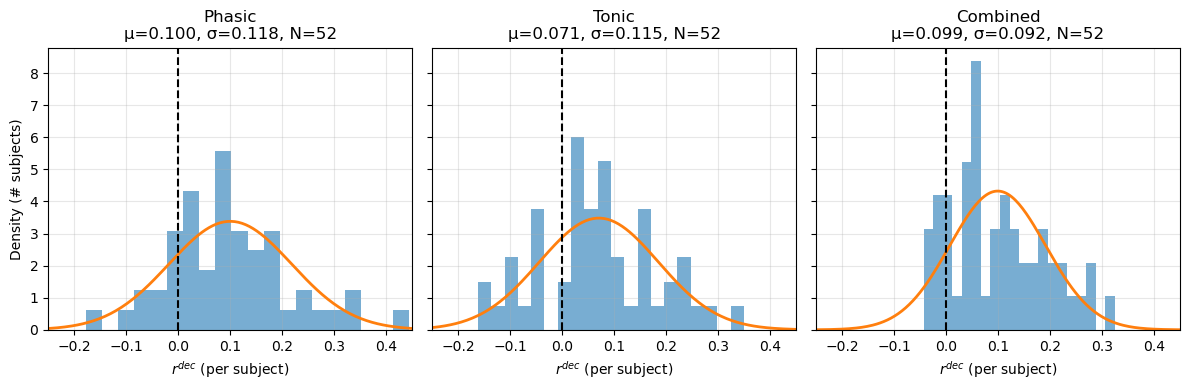


One-sided Fisher-z t-test (H1: mean r > 0), subject-level values:
Phasic: {'N': 52, 'mean_z': 0.10230097046173162, 'sd_z': 0.12325770283427552, 'mean_r': 0.10194558156971753, 'sd_r': 0.11914819523950924, 'ci_r': (0.06788125510370435, 0.13577249868126484), 't': 5.9850441156677165, 'p_one_sided': 1.0823899834576846e-07, 'p_two_sided': 2.1647799669153692e-07, 'p_holm': 4.3295599338307383e-07}
Tonic: {'N': 52, 'mean_z': 0.07193452816289338, 'sd_z': 0.11786342600078326, 'mean_r': 0.0718107075417471, 'sd_r': 0.11569661412743057, 'ci_r': (0.03910119520497954, 0.10436648701267885), 't': 4.401087573441093, 'p_one_sided': 2.756730370217799e-05, 'p_two_sided': 5.513460740435598e-05, 'p_holm': 5.513460740435598e-05}
Combined: {'N': 52, 'mean_z': 0.100822917187473, 'sd_z': 0.09521215579043979, 'mean_r': 0.1004826701900618, 'sd_r': 0.09315989234866422, 'ci_r': (0.07417917456655058, 0.1266464510207649), 't': 7.636045936432721, 'p_one_sided': 2.7029996364829236e-10, 'p_two_sided': 5.405999272965847e-

In [5]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_1samp
import eelbrain

# -------------------------------------------------------------------
# Your loader (unchanged)
# -------------------------------------------------------------------
def get_decoder(trf_dir: Path):
    cases = []
    for f in trf_dir.glob("dec_eeg_to_ppd_sub-*_l*.pickle"):
        m = re.match(r"dec_eeg_to_ppd_sub-(\d+)_l(\d+)\.pickle", f.name)
        if not m:
            continue
        subj = f"S{int(m.group(1)):03d}"
        load_val = int(m.group(2))

        dec = eelbrain.load.unpickle(f)

        trf = dec.h_scaled
        r_val = float(dec.r)
        ve = float(dec.proportion_explained) * 100

        cases.append([subj, load_val, trf, r_val, ve])

    dataset_dec = eelbrain.Dataset.from_caselist(
        ['subject', 'load', 'trf_dec', 'r', 'var_explained'],
        cases,
        random='subject'
    )
    return dataset_dec


# -------------------------------------------------------------------
# Paths for the three models
# -------------------------------------------------------------------
TRF_PHASIC   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\ran12\TRF")
TRF_TONIC    = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran04\TRF")
TRF_COMBINED = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\TRF")

ds_phasic   = get_decoder(TRF_PHASIC)
ds_tonic    = get_decoder(TRF_TONIC)
ds_combined = get_decoder(TRF_COMBINED)


# -------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------
# If you want only some loads, set e.g. LOADS_TO_USE = [13]  (or [5,9,13], or None for all)
LOADS_TO_USE = None

# Plot per-subject (aggregated across loads) or per-subject-per-load
PLOT_BY_LOAD = False   # True -> plot 3x3 grid (model x load)

# Aggregation across loads for each subject:
#   "fisher_mean" is typically the best default for correlations
AGG_METHOD = "fisher_mean"   # alternatives: "mean_r" (plain mean of r), "median_r"


# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------
def _to_np(x):
    # eelbrain Var/Factor usually has .x; fall back otherwise
    return np.asarray(x.x if hasattr(x, "x") else x)

def dataset_to_df(ds):
    df = pd.DataFrame({
        "subject": _to_np(ds["subject"]).astype(str),
        "load":    _to_np(ds["load"]).astype(int),
        "r":       _to_np(ds["r"]).astype(float),
    })
    df = df[np.isfinite(df["r"])]
    if LOADS_TO_USE is not None:
        df = df[df["load"].isin(list(LOADS_TO_USE))]
    return df

def fisher_mean_r(rs):
    rs = np.asarray(rs, float)
    rs = rs[np.isfinite(rs)]
    rs = np.clip(rs, -0.999999, 0.999999)
    return float(np.tanh(np.mean(np.arctanh(rs)))) if len(rs) else np.nan

def reduce_to_subject_values(df, agg_method="fisher_mean"):
    if agg_method == "fisher_mean":
        out = (df.groupby("subject")["r"]
                 .apply(fisher_mean_r)
                 .reset_index(name="r_sub"))
    elif agg_method == "mean_r":
        out = (df.groupby("subject")["r"]
                 .mean()
                 .reset_index(name="r_sub"))
    elif agg_method == "median_r":
        out = (df.groupby("subject")["r"]
                 .median()
                 .reset_index(name="r_sub"))
    else:
        raise ValueError(f"Unknown agg_method: {agg_method}")
    out = out[np.isfinite(out["r_sub"])]
    return out

def holm_adjust(pvals):
    """Holm step-down adjustment. Returns adjusted p-values in original order."""
    pvals = np.asarray(pvals, float)
    m = len(pvals)
    order = np.argsort(pvals)
    p_sorted = pvals[order]

    adj_sorted = (m - np.arange(m)) * p_sorted
    adj_sorted = np.minimum(adj_sorted, 1.0)
    adj_sorted = np.maximum.accumulate(adj_sorted)

    adj = np.empty_like(adj_sorted)
    adj[order] = adj_sorted
    return adj


from scipy.stats import t as tdist

def one_sided_t_on_r(r, alternative="greater", alpha=0.05):
    r = np.asarray(r, float)
    r = r[np.isfinite(r)]
    r = np.clip(r, -0.999999, 0.999999)
    z = np.arctanh(r)

    tstat, p2 = ttest_1samp(z, 0.0)

    if alternative == "greater":
        p1 = p2/2 if tstat > 0 else 1 - p2/2
    elif alternative == "less":
        p1 = p2/2 if tstat < 0 else 1 - p2/2
    else:
        raise ValueError

    N = len(z)
    mean_z = float(np.mean(z)) if N else np.nan
    sd_z   = float(np.std(z, ddof=1)) if N > 1 else np.nan
    mean_r = float(np.tanh(mean_z)) if np.isfinite(mean_z) else np.nan
    sd_r   = float(np.std(r, ddof=1)) if N > 1 else np.nan

    # ---- 95% CI for the mean (in z, then back-transform to r) ----
    if N > 1 and np.isfinite(sd_z):
        se_z = sd_z / np.sqrt(N)
        tcrit = tdist.ppf(1 - alpha/2, df=N-1)
        ci_z = (mean_z - tcrit * se_z, mean_z + tcrit * se_z)
        ci_r = (float(np.tanh(ci_z[0])), float(np.tanh(ci_z[1])))
    else:
        ci_z = (np.nan, np.nan)
        ci_r = (np.nan, np.nan)

    return {
        "N": int(N),
        "mean_z": mean_z,
        "sd_z": sd_z,
        "mean_r": mean_r,
        "sd_r": sd_r,
        "ci_r": ci_r,          # <-- add this
        "t": float(tstat),
        "p_one_sided": float(p1),
        "p_two_sided": float(p2),
    }



# -------------------------------------------------------------------
# Build model DataFrames
# -------------------------------------------------------------------
models = {
    "Phasic":   dataset_to_df(ds_phasic),
    "Tonic":    dataset_to_df(ds_tonic),
    "Combined": dataset_to_df(ds_combined),
}

for name, df in models.items():
    print(f"{name}: {len(df)} rows (subject×load). Subjects={df['subject'].nunique()}")

# -------------------------------------------------------------------
# Plot histograms
# -------------------------------------------------------------------
# Choose consistent x-range for correlations (edit if you want)
x_min, x_max = -0.25, 0.45
x = np.linspace(x_min, x_max, 200)

if not PLOT_BY_LOAD:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

    for ax, (title, df) in zip(axes, models.items()):
        sub_df = reduce_to_subject_values(df, agg_method=AGG_METHOD)
        vals = sub_df["r_sub"].to_numpy()

        if len(vals) == 0:
            ax.set_title(f"{title}\n(no data)")
            ax.set_xlim(x_min, x_max)
            ax.axvline(0, linestyle="--", color="k")
            ax.grid(True, alpha=0.3)
            continue

        ax.hist(vals, bins=20, alpha=0.6, density=True)

        mu, sigma = norm.fit(vals)
        ax.plot(x, norm.pdf(x, mu, sigma), linewidth=2)

        ax.axvline(0, linestyle="--", color="k")
        ax.set_xlim(x_min, x_max)
        ax.set_title(f"{title}\nμ={mu:.3f}, σ={sigma:.3f}, N={len(vals)}")
        ax.set_xlabel(r"$r^{dec}$ (per subject)")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Density (# subjects)")
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------
    # One-sided t-tests + Holm correction across the three models
    # -------------------------------------------------------------------
    print("\nOne-sided Fisher-z t-test (H1: mean r > 0), subject-level values:")

    stats_by_model = {}
    for title, df in models.items():
        sub_df = reduce_to_subject_values(df, agg_method=AGG_METHOD)
        stats_by_model[title] = one_sided_t_on_r(sub_df["r_sub"].to_numpy(), "greater")

    # Holm-correct across models (Phasic, Tonic, Combined)
    model_order = list(models.keys())

    # Choose which p-values to correct:
    #   - two-sided (recommended if your thesis uses two-sided by default)
    p_raw = [stats_by_model[m]["p_two_sided"] for m in model_order]
    # If you instead want Holm on the one-sided p-values, use:
    # p_raw = [stats_by_model[m]["p_one_sided"] for m in model_order]

    p_holm = holm_adjust(p_raw)

    for m, ph in zip(model_order, p_holm):
        stats_by_model[m]["p_holm"] = float(ph)

    for m in model_order:
        print(f"{m}: {stats_by_model[m]}")


else:
    # 3x3 grid: model x load
    loads = [5, 9, 13] if LOADS_TO_USE is None else list(LOADS_TO_USE)
    fig, axes = plt.subplots(len(loads), 3, figsize=(12, 3.8*len(loads)), sharey=True)

    if len(loads) == 1:
        axes = np.array([axes])  # keep 2D

    for i, L in enumerate(loads):
        for j, (title, df) in enumerate(models.items()):
            ax = axes[i, j]
            dfL = df[df["load"] == L]
            # here we still aggregate within subject (in case duplicates exist)
            sub_df = reduce_to_subject_values(dfL, agg_method=AGG_METHOD)
            vals = sub_df["r_sub"].to_numpy()

            if len(vals) == 0:
                ax.set_title(f"{title} | load {L}\n(no data)")
                ax.set_xlim(x_min, x_max)
                ax.axvline(0, linestyle="--", color="k")
                ax.grid(True, alpha=0.3)
                continue

            ax.hist(vals, bins=20, alpha=0.6, density=True)
            mu, sigma = norm.fit(vals)
            ax.plot(x, norm.pdf(x, mu, sigma), linewidth=2)

            ax.axvline(0, linestyle="--", color="k")
            ax.set_xlim(x_min, x_max)
            ax.set_title(f"{title} | load {L}\nμ={mu:.3f}, σ={sigma:.3f}, N={len(vals)}")
            ax.set_xlabel(r"$r^{dec}$")
            ax.grid(True, alpha=0.3)

    axes[0, 0].set_ylabel("Density (# subjects)")
    plt.tight_layout()
    plt.show()

    print("\nOne-sided Fisher-z t-test (H1: mean r > 0), per-load subject-level values:")
    for L in loads:
        for title, df in models.items():
            dfL = df[df["load"] == L]
            sub_df = reduce_to_subject_values(dfL, agg_method=AGG_METHOD)
            stats = one_sided_t_on_r(sub_df["r_sub"].to_numpy(), "greater")
            print(f"{title} | load {L}: {stats}")


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

# --- settings ---
AGG_METHOD = "fisher_mean"   # subject-level aggregation across loads
LOADS_TO_USE = None          # or e.g. [5, 9, 13]

# --- build per-model subject-level r ---
dfP = reduce_to_subject_values(dataset_to_df(ds_phasic),   agg_method=AGG_METHOD).rename(columns={"r_sub":"Phasic"})
dfT = reduce_to_subject_values(dataset_to_df(ds_tonic),    agg_method=AGG_METHOD).rename(columns={"r_sub":"Tonic"})
dfC = reduce_to_subject_values(dataset_to_df(ds_combined), agg_method=AGG_METHOD).rename(columns={"r_sub":"Combined"})

# --- merge to keep only subjects present in ALL 3 (paired design) ---
wide = (dfP.merge(dfT, on="subject", how="inner")
          .merge(dfC, on="subject", how="inner")
          .set_index("subject"))

print("N subjects in all 3 models:", len(wide))
# (optional) see who got dropped:
all_subs = set(dfP.subject) | set(dfT.subject) | set(dfC.subject)
kept = set(wide.index)
dropped = sorted(all_subs - kept)
if dropped:
    print("Dropped subjects (missing in ≥1 model):", dropped)

# --- Fisher z transform for stats ---
eps = 1e-6
zwide = np.arctanh(np.clip(wide, -1+eps, 1-eps))

# --- long format for RM ANOVA ---
df_long = (zwide.reset_index()
                 .melt(id_vars="subject", var_name="model", value_name="z"))

# --- RM ANOVA (within-subject factor: model) ---
aov = AnovaRM(data=df_long, depvar="z", subject="subject", within=["model"]).fit()
print("\nRepeated-measures ANOVA on Fisher z:")
print(aov)

# --- post-hoc paired t-tests (still on Fisher z) ---
pairs = [("Combined", "Tonic"), ("Combined", "Phasic"), ("Tonic", "Phasic")]
pvals = []
results = []

for a, b in pairs:
    t, p = ttest_rel(zwide[a].values, zwide[b].values, nan_policy="omit")
    # effect size: Cohen's dz for paired (mean(diff)/sd(diff))
    diff = (zwide[a] - zwide[b]).values
    dz = diff.mean() / diff.std(ddof=1)
    results.append((a, b, float(t), float(p), float(dz)))
    pvals.append(p)

# Holm correction (good default)
rej, p_corr, _, _ = multipletests(pvals, method="holm")

print("\nPost-hoc paired t-tests on Fisher z (Holm-corrected):")
for (a, b, t, p, dz), pc, rj in zip(results, p_corr, rej):
    print(f"{a} vs {b}: t={t:.3f}, p={p:.4g}, p_holm={pc:.4g}, dz={dz:.3f}, reject={bool(rj)}")

# --- (optional) report descriptive means back in r-space ---
print("\nDescriptives (mean Fisher z -> back to r):")
for col in ["Phasic", "Tonic", "Combined"]:
    mean_r = np.tanh(zwide[col].mean())
    sd_r = wide[col].std(ddof=1)
    print(f"{col}: mean_r≈{mean_r:.3f}, sd_r={sd_r:.3f}")


N subjects in all 3 models: 52

Repeated-measures ANOVA on Fisher z:
               Anova
      F Value Num DF  Den DF  Pr > F
------------------------------------
model  1.9816 2.0000 102.0000 0.1431


Post-hoc paired t-tests on Fisher z (Holm-corrected):
Combined vs Tonic: t=2.752, p=0.008187, p_holm=0.02456, dz=0.382, reject=True
Combined vs Phasic: t=-0.086, p=0.9316, p_holm=0.9316, dz=-0.012, reject=False
Tonic vs Phasic: t=-1.381, p=0.1732, p_holm=0.3465, dz=-0.192, reject=False

Descriptives (mean Fisher z -> back to r):
Phasic: mean_r≈0.102, sd_r=0.119
Tonic: mean_r≈0.072, sd_r=0.116
Combined: mean_r≈0.100, sd_r=0.093


: 

TIME SERIES with h_dec (average of all folds)

In [5]:
import re
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from eelbrain import load, convolve


_DEC_RE = re.compile(r"dec_eeg_to_ppd_(sub-\d{3})_l(\d+)\.pickle$")


def zscore_trials_2d(a, eps=1e-12):
    """
    Z-score each trial over time.
    a: (n_trials, T)
    """
    a = np.asarray(a, float)
    m = np.nanmean(a, axis=1, keepdims=True)
    s = np.nanstd(a, axis=1, keepdims=True)
    s = np.where(s < eps, 1.0, s)
    return (a - m) / s


def save_panel_trials(panel_trials, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "wb") as f:
        pickle.dump(panel_trials, f, protocol=pickle.HIGHEST_PROTOCOL)


def _sem(stack):
    n = stack.shape[0]
    if n <= 1:
        return np.zeros(stack.shape[1], dtype=float)
    return stack.std(axis=0, ddof=1) / np.sqrt(n)


def _zscore_mean_and_sem(mu, sem, eps=1e-12):
    """
    Z-score the mean time series over time; scale SEM accordingly.
    """
    mu = np.asarray(mu, float)
    sem = np.asarray(sem, float)
    m = mu.mean()
    s = mu.std(ddof=0)
    if s < eps:
        return mu * 0.0, sem * 0.0
    return (mu - m) / s, sem / s


def extract_trials_for_plot_decoder_convolve(
    trf_dir: Path,
    ds_dir: Path,
    load_value: int = 13,
    min_trials: int = 10,
    z_per_trial: bool = True,
):
    """
    Returns:
      panel_trials = {("memory", load_value): {"pupil": [sub_mean...], "pred":[sub_mean...], "subjects":[...]}}
    Uses convolve(dec.h_scaled, x) to obtain predictions.
    """
    trf_dir = Path(trf_dir)
    ds_dir = Path(ds_dir)

    panel_trials = {("memory", load_value): {"pupil": [], "pred": [], "subjects": []}}

    dec_files = sorted(trf_dir.glob(f"dec_eeg_to_ppd_sub-*_l{load_value}.pickle"))
    if not dec_files:
        print(f"[WARN] No decoders found in {trf_dir}")
        return panel_trials

    for dec_path in dec_files:
        m = _DEC_RE.search(dec_path.name)
        if not m:
            continue
        subj = m.group(1)
        lval = int(m.group(2))
        if lval != load_value:
            continue
        print(f"[INFO] Processing subject {subj}, load {load_value}")

        ds_path = ds_dir / f"ds_{subj}_l{load_value}.pickle"
        if not ds_path.exists():
            print(f"[SKIP] {subj}: missing dataset {ds_path.name}")
            continue

        dec = load.unpickle(dec_path)
        ds  = load.unpickle(ds_path)

        # true response
        y = ds[dec.y] if getattr(dec, "y", None) in ds else ds["ppd"]

        # predictors
        if getattr(dec, "x", None) is None:
            print(f"[SKIP] {subj}: dec.x is None")
            continue
        x_names = [dec.x] if isinstance(dec.x, str) else list(dec.x)
        x_ndvars = [ds[name] for name in x_names]

        # kernel(s)
        h = getattr(dec, "h_scaled", None)
        if h is None:
            h = getattr(dec, "h", None)
        if h is None:
            print(f"[SKIP] {subj}: no h_scaled/h on decoder")
            continue
        if not isinstance(h, tuple):
            h = (h,)

        # predict all trials
        y_pred = convolve(h, x_ndvars)

        yt = np.asarray(y.x)       # (n_trials, T)
        yp = np.asarray(y_pred.x)  # (n_trials, T)

        if yt.ndim != 2 or yp.ndim != 2:
            print(f"[SKIP] {subj}: unexpected shapes yt={yt.shape}, yp={yp.shape}")
            continue

        n_trials = yt.shape[0]
        if n_trials < min_trials:
            print(f"[SKIP] {subj}: only {n_trials} trials (min_trials={min_trials})")
            continue

        # per-trial zscore (recommended so true/pred comparable)
        if z_per_trial:
            yt = zscore_trials_2d(yt)
            yp = zscore_trials_2d(yp)

        # subject-mean trace (each subject contributes equally)
        yt_mu = yt.mean(axis=0)
        yp_mu = yp.mean(axis=0)

        panel_trials[("memory", load_value)]["pupil"].append(yt_mu)
        panel_trials[("memory", load_value)]["pred"].append(yp_mu)
        panel_trials[("memory", load_value)]["subjects"].append(subj)

    return panel_trials


In [17]:
def plot_components_decoder_grid(
    all_panel_trials,
    cond="memory",
    load=13,
    components_order=("Combined", "Tonic", "Phasic"),
    fs=100.0,
    max_time=24.0,
):
    keymap = {k.lower(): k for k in all_panel_trials.keys()}
    comps = [keymap.get(c.lower(), c) for c in components_order]
    comps = [c for c in comps if c in all_panel_trials]

    fig, axes = plt.subplots(1, len(comps), figsize=(3.6 * len(comps), 2.6), sharey=True)
    axes = np.atleast_1d(axes)

    # choose common length across components
    Lmins = []
    for comp in comps:
        cell = all_panel_trials[comp].get((cond, load), {})
        pup_list = cell.get("pupil", [])
        pred_list = cell.get("pred", [])
        if pup_list and pred_list:
            Lmins.append(min(min(map(len, pup_list)), min(map(len, pred_list))))
    if not Lmins:
        print("[WARN] Nothing to plot.")
        return fig

    L = min(Lmins)
    t = np.arange(L) / fs
    keep = t <= max_time
    t = t[keep]

    for ax, comp in zip(axes, comps):
        ax.set_title(comp, fontsize=12)

        cell = all_panel_trials[comp].get((cond, load), {})
        pup_list = cell.get("pupil", [])
        pred_list = cell.get("pred", [])

        if not pup_list or not pred_list:
            ax.set_visible(False)
            continue

        pup_stack  = np.stack([p[:L] for p in pup_list], axis=0)[:, keep]
        pred_stack = np.stack([p[:L] for p in pred_list], axis=0)[:, keep]

        pup_mu = pup_stack.mean(axis=0)
        pup_sem = _sem(pup_stack)
        pred_mu = pred_stack.mean(axis=0)
        pred_sem = _sem(pred_stack)

        # (optional) z-score the grand-average traces over time (same style as your ridge plots)
        pup_mu_z, pup_sem_z = _zscore_mean_and_sem(pup_mu, pup_sem)
        pred_mu_z, pred_sem_z = _zscore_mean_and_sem(pred_mu, pred_sem)

        ln1, = ax.plot(t, pup_mu_z, lw=1.6, label="y", color="green")
        ax.fill_between(t, pup_mu_z - pup_sem_z, pup_mu_z + pup_sem_z, alpha=0.25)

        ln2, = ax.plot(t, pred_mu_z, color="black", lw=0.8, label=r"$h \ast X$")
        ax.fill_between(t, pred_mu_z - pred_sem_z, pred_mu_z + pred_sem_z, color="black", alpha=0.12)

        ax.axvline(0, ls="--", c="k", lw=0.7)
        ax.set_xlim(0, max_time)
        ax.set_xlabel("Time (s)")

    axes[0].set_ylabel("z-scored grand-average")
    axes[0].legend(frameon=True)
    fig.tight_layout()
    return fig



=== Combined ===
[INFO] Processing subject sub-033, load 13
[INFO] Processing subject sub-034, load 13
[INFO] Processing subject sub-036, load 13
[INFO] Processing subject sub-038, load 13
[INFO] Processing subject sub-039, load 13
[INFO] Processing subject sub-040, load 13
[INFO] Processing subject sub-041, load 13
[INFO] Processing subject sub-042, load 13
[INFO] Processing subject sub-043, load 13
[INFO] Processing subject sub-044, load 13
[INFO] Processing subject sub-045, load 13
[INFO] Processing subject sub-047, load 13
[INFO] Processing subject sub-048, load 13
[INFO] Processing subject sub-049, load 13
[INFO] Processing subject sub-050, load 13
[INFO] Processing subject sub-051, load 13
[INFO] Processing subject sub-052, load 13
[INFO] Processing subject sub-054, load 13
[INFO] Processing subject sub-055, load 13
[INFO] Processing subject sub-056, load 13
[INFO] Processing subject sub-057, load 13
[INFO] Processing subject sub-058, load 13
[INFO] Processing subject sub-059, l

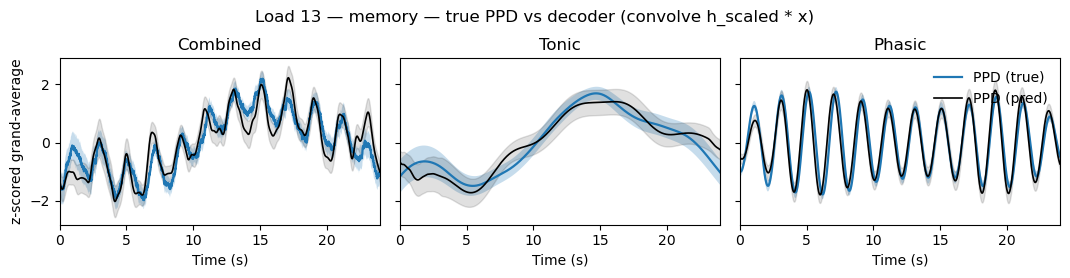

Saved: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\plots_decoder_timeseries\grand_average_decoder_load13_memory.png


In [ ]:
TRF_PHASIC   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\ran12\TRF")
TRF_TONIC    = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran04\TRF")
TRF_COMBINED = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\TRF")

COMPONENTS = {
    "Combined": {"trf_dir": TRF_COMBINED, "ds_dir": TRF_COMBINED.parent / "datasets"},
    "Tonic":    {"trf_dir": TRF_TONIC,    "ds_dir": TRF_TONIC.parent / "datasets"},
    "Phasic":   {"trf_dir": TRF_PHASIC,   "ds_dir": TRF_PHASIC.parent / "datasets"},
}

OUT_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\plots_decoder_timeseries")
OUT_DIR.mkdir(parents=True, exist_ok=True)

all_panel_trials = {}

for comp_name, cfg in COMPONENTS.items():
    print(f"\n=== {comp_name} ===")
    panel_trials = extract_trials_for_plot_decoder_convolve(
        trf_dir=cfg["trf_dir"],
        ds_dir=cfg["ds_dir"],
        load_value=13,
        min_trials=10,      # adjust to whatever “enough trials” means for you
        z_per_trial=True,   # matches your single-trial plotting idea
    )
    all_panel_trials[comp_name] = panel_trials

    pkl_path = OUT_DIR / f"panel_trials_{comp_name.lower()}_decoder.pkl"
    save_panel_trials(panel_trials, pkl_path)
    print(f"Saved: {pkl_path}")

fig = plot_components_decoder_grid(all_panel_trials, cond="memory", load=13, fs=100.0, max_time=26.0)
#fig.suptitle("Load 13 — memory — true PPD vs decoder (convolve h_scaled * x)", y=1.05)

out_path = OUT_DIR / "grand_average_decoder_load13_memory.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

TIME SERIES OF TEST y_pred vs y_true

In [1]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from eelbrain import load as eb_load

_DEC_RE = re.compile(r"dec_eeg_to_ppd_(sub-\d{3})_l(\d+)\.pickle$")

def zscore_trials_2d(a, eps=1e-12):
    """Z-score each trial over time. a: (n_trials, T)."""
    a = np.asarray(a, float)
    m = np.nanmean(a, axis=1, keepdims=True)
    s = np.nanstd(a, axis=1, keepdims=True)
    s = np.where(s < eps, 1.0, s)
    return (a - m) / s

def _sem(stack):
    n = stack.shape[0]
    if n <= 1:
        return np.zeros(stack.shape[1], dtype=float)
    return stack.std(axis=0, ddof=1) / np.sqrt(n)

def _zscore_mean_and_sem(mu, sem, eps=1e-12):
    """Z-score the mean time series over time; scale SEM accordingly."""
    mu = np.asarray(mu, float)
    sem = np.asarray(sem, float)
    m = mu.mean()
    s = mu.std(ddof=0)
    if s < eps:
        return mu * 0.0, sem * 0.0
    return (mu - m) / s, sem / s

def extract_trials_for_plot_decoder_cv(
    trf_dir: Path,
    ds_dir: Path,
    *,
    loads=(5, 9, 13),
    min_trials=10,
    z_per_trial=True,
    scale="original",   # cross_predict scale
):
    """
    Returns:
      panel_trials[(load)] = {"y": [sub_mean...], "yhat": [sub_mean...], "subjects":[...]}
    using held-out predictions from dec.cross_predict().
    """
    trf_dir = Path(trf_dir)
    ds_dir  = Path(ds_dir)

    panel_trials = {int(l): {"y": [], "yhat": [], "subjects": []} for l in loads}

    for load_val in loads:
        dec_files = sorted(trf_dir.glob(f"dec_eeg_to_ppd_sub-*_l{load_val}.pickle"))
        if not dec_files:
            print(f"[WARN] No decoders found for load {load_val} in {trf_dir}")
            continue

        for dec_path in dec_files:
            m = _DEC_RE.search(dec_path.name)
            if not m:
                continue
            subj = m.group(1)
            lval = int(m.group(2))
            if lval != int(load_val):
                continue

            ds_path = ds_dir / f"ds_{subj}_l{load_val}.pickle"
            if not ds_path.exists():
                print(f"[SKIP] {subj} load {load_val}: missing {ds_path.name}")
                continue

            dec = eb_load.unpickle(dec_path)
            ds  = eb_load.unpickle(ds_path)

            # True response NDVar (case, time)
            y_true = ds[dec.y] if (getattr(dec, "y", None) in ds) else ds["ppd"]

            # Held-out (CV) predictions NDVar (case, time)
            y_pred = dec.cross_predict(data=ds, scale=scale)

            # Align check
            if y_true.x.shape != y_pred.x.shape:
                print(f"[SKIP] {subj} load {load_val}: shape mismatch {y_true.x.shape} vs {y_pred.x.shape}")
                continue

            yt = np.asarray(y_true.x, float)  # (n_trials, T)
            yp = np.asarray(y_pred.x, float)

            if yt.ndim != 2 or yp.ndim != 2:
                print(f"[SKIP] {subj} load {load_val}: unexpected dims yt={yt.shape}, yp={yp.shape}")
                continue

            n_trials = yt.shape[0]
            if n_trials < min_trials:
                print(f"[SKIP] {subj} load {load_val}: only {n_trials} trials (min_trials={min_trials})")
                continue

            # Optional: per-trial z-scoring over time
            if z_per_trial:
                yt = zscore_trials_2d(yt)
                yp = zscore_trials_2d(yp)

            # Subject mean (each subject contributes equally)
            yt_mu = np.nanmean(yt, axis=0)
            yp_mu = np.nanmean(yp, axis=0)

            panel_trials[int(load_val)]["y"].append(yt_mu)
            panel_trials[int(load_val)]["yhat"].append(yp_mu)
            panel_trials[int(load_val)]["subjects"].append(subj)

    return panel_trials


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decoder_cv_grid_load13_green(
    all_comp_trials,
    *,
    load_val=13,
    components_order=("Combined", "Tonic", "Phasic"),
    fs=100.0,
    max_time=24.0,
    zscore_means=True,
):
    keymap = {k.lower(): k for k in all_comp_trials.keys()}
    comps = [keymap.get(c.lower(), c) for c in components_order]
    comps = [c for c in comps if c in all_comp_trials]

    fig, axes = plt.subplots(
        1, len(comps),
        figsize=(3.6 * len(comps), 2.6),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    # common length across components
    Lmins = []
    for comp in comps:
        cell = all_comp_trials[comp].get(int(load_val), {})
        ys = cell.get("y", [])
        yh = cell.get("yhat", [])
        if ys and yh:
            Lmins.append(min(min(map(len, ys)), min(map(len, yh))))
    if not Lmins:
        print("[WARN] Nothing to plot for load", load_val)
        return fig

    L = min(Lmins)
    t = np.arange(L) / fs
    keep = t <= max_time
    t = t[keep]

    for ax, comp in zip(axes, comps):
        ax.set_title(comp, fontsize=12)

        cell = all_comp_trials[comp].get(int(load_val), {})
        ys = cell.get("y", [])
        yh = cell.get("yhat", [])
        if not ys or not yh:
            ax.set_visible(False)
            continue

        y_stack  = np.stack([y[:L] for y in ys], axis=0)[:, keep]
        yh_stack = np.stack([y[:L] for y in yh], axis=0)[:, keep]

        y_mu  = y_stack.mean(axis=0)
        y_se  = _sem(y_stack)
        yh_mu = yh_stack.mean(axis=0)
        yh_se = _sem(yh_stack)

        if zscore_means:
            y_mu,  y_se  = _zscore_mean_and_sem(y_mu,  y_se)
            yh_mu, yh_se = _zscore_mean_and_sem(yh_mu, yh_se)

        # ✅ both green, distinguish by line style
        ln1, = ax.plot(t, y_mu,  lw=1.6, linestyle="-",  label=r"$\mathbf{y}^{val}$", color="green")
        ax.fill_between(t, y_mu - y_se, y_mu + y_se, alpha=0.18, color="green")

        ln2, = ax.plot(t, yh_mu, lw=1.0, linestyle="--", label=r"$\hat{\mathbf{y}}^{val}$", color="black")
        ax.fill_between(t, yh_mu - yh_se, yh_mu + yh_se, alpha=0.10, color="black")

        ax.axvline(0, ls="--", c="k", lw=0.7)
        ax.set_xlim(0, max_time)
        ax.set_xlabel("Time (s)")

    axes[0].set_ylabel("Seq. length 13")

    # legend on the last panel
    axes[-1].legend(frameon=True, loc="upper right")
    fig.tight_layout()
    return fig



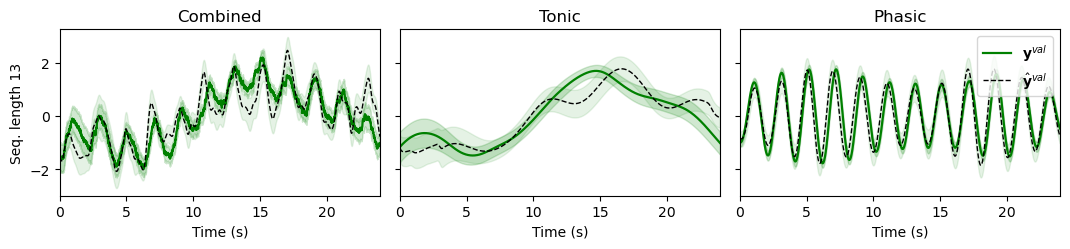

In [ ]:
from pathlib import Path

TRF_PHASIC   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\save\TRF")
TRF_TONIC    = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran01\TRF")
TRF_COMBINED = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\save\TRF")

COMPONENTS = {
    "Combined": {"trf_dir": TRF_COMBINED, "ds_dir": TRF_COMBINED.parent / "datasets"},
    "Tonic":    {"trf_dir": TRF_TONIC,    "ds_dir": TRF_TONIC.parent / "datasets"},
    "Phasic":   {"trf_dir": TRF_PHASIC,   "ds_dir": TRF_PHASIC.parent / "datasets"},
}

loads = (5, 9, 13)

all_comp_trials = {}
for comp, cfg in COMPONENTS.items():
    print(f"\n=== {comp} ===")
    all_comp_trials[comp] = extract_trials_for_plot_decoder_cv(
        cfg["trf_dir"], cfg["ds_dir"],
        loads=loads,
        min_trials=10,
        z_per_trial=True,
        scale="original",
    )

fig = plot_decoder_cv_grid_load13_green(all_comp_trials, load_val=13, fs=100.0, max_time=24.0, zscore_means=True)
plt.show()

In [20]:
fig = plot_decoder_cv_grid_load13_green(all_comp_trials, load_val=13, fs=100.0, max_time=24.0, zscore_means=True)
plt.show()
